In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [ ]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

Extracted Spatial Field 'a' Shape: (16384, 1)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (16384, 1)


E0710 18:26:21.755277   97906 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0710 18:26:21.763022   97795 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [4]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [5]:
epochs = 1000
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        u_pred = nn.Dense(1, use_bias=False)(h)
        return u_pred

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [6]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [7]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 2000 
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

Pure Data-Loss Sanity Check:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Data MSE Loss: 1.3431e+00 | Learned Sigma: 3.0476
Epoch 100 | Data MSE Loss: 1.9469e-04 | Learned Sigma: 3.0434
Epoch 200 | Data MSE Loss: 7.1629e-05 | Learned Sigma: 3.0429
Epoch 300 | Data MSE Loss: 4.1587e-05 | Learned Sigma: 3.0425
Epoch 400 | Data MSE Loss: 3.1163e-05 | Learned Sigma: 3.0421
Epoch 500 | Data MSE Loss: 2.2780e-05 | Learned Sigma: 3.0417
Epoch 600 | Data MSE Loss: 1.8359e-05 | Learned Sigma: 3.0415
Epoch 700 | Data MSE Loss: 1.5275e-05 | Learned Sigma: 3.0412
Epoch 800 | Data MSE Loss: 1.6930e-05 | Learned Sigma: 3.0410
Epoch 900 | Data MSE Loss: 1.3220e-05 | Learned Sigma: 3.0408


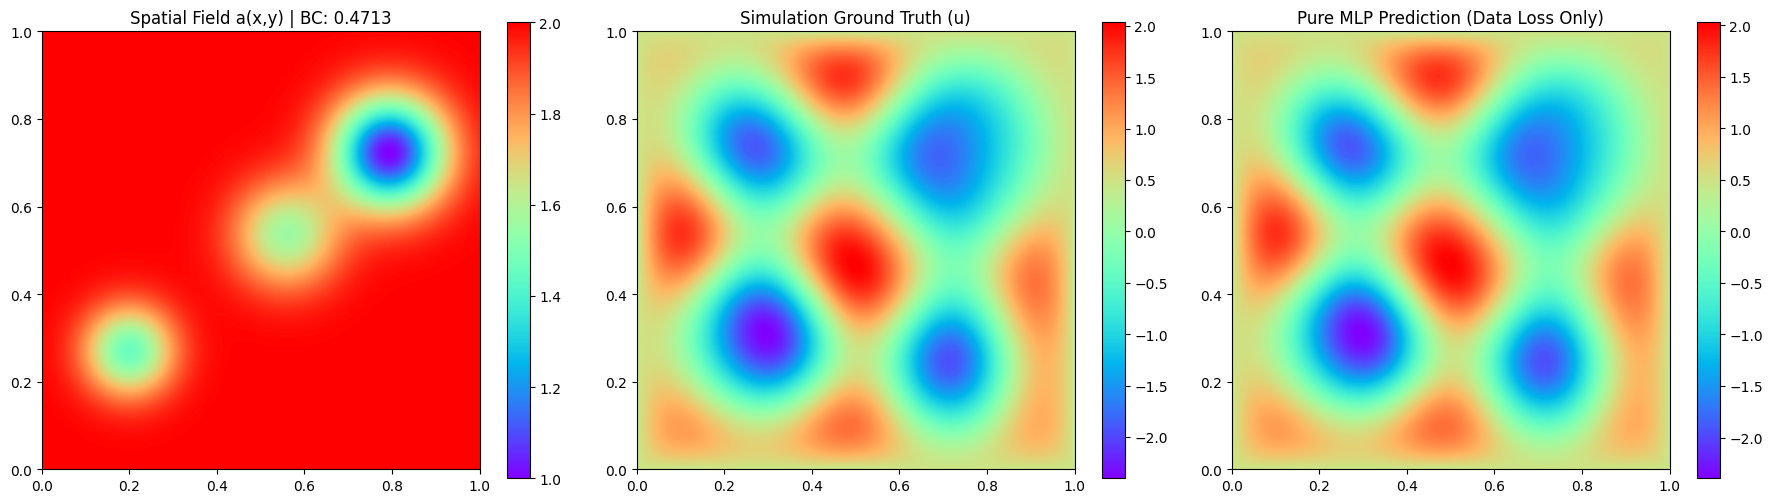

In [8]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [9]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

Weights successfully saved to pretrained_helmholtz_mlp.pkl
Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [10]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# Extract and apply the learned sigma to B_matrix_base
learned_raw_sigma = params['params']['raw_sigma'][0]
learned_sigma = jax.nn.softplus(learned_raw_sigma)
print(f"Applying learned bandwidth (sigma = {learned_sigma:.4f}) to the features...")

# DEFINE FROZEN MODEL (NO FINAL LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(1), (1,)) # this is fallback, extracted sigma is applied to B_matrix_base
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = nn.tanh(h)
            
        return h # Outputs shape (256,)

model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

# BUILD THE PHYSICS & BC MATRICES (SAMPLED)
omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

rng = jax.random.PRNGKey(42)
total_points = x.shape[0]
spatial_batch_size = 2000 # Same batch size used in your training loop

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val):
    H = model_frozen.apply(frozen_params, x_val, y_val)
    
    # Isolate the forward pass for derivatives
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # Second derivatives using purely forward-mode autodiff 
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
    
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    return -Laplacian_H - omega_sq * a_val * H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    x_chunk = x_sampled[i:i + chunk_size]
    y_chunk = y_sampled[i:i + chunk_size]
    a_chunk = a_sampled[i:i + chunk_size]
    
    A_chunk = compute_A_pde_vmap(x_chunk, y_chunk, a_chunk)
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.zeros((spatial_batch_size, 1))

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

# HYPERPARAMETER SWEEP
lambda_bcs = [1e2, 1e3, 1e4, 1e6, 1e8, 1e9, 1e10, 1e11, 1e12]
tik_regs = [1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

all_sweep_preds = {}

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B)
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        all_sweep_preds[(lmbda, tik)] = u_pred_sweep
        
        # Track the best performing combination (still based on MSE)
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")

Applying learned bandwidth (sigma = 3.0406) to the features...
Compiling and evaluating PDE matrices for 2000 sampled points...
Compiling and evaluating BC matrices...
Finished building matrices! A_pde shape: (2000, 256), A_bc shape: (508, 256)

Starting Sweep:
--------------------------------------------------------------------------------
Lam: 1.0e+02 | Tik: 1.0e-03 | MSE: 8.25e-01 | PDE: 1.51e-03 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-04 | MSE: 8.25e-01 | PDE: 1.51e-03 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-05 | MSE: 8.25e-01 | PDE: 1.51e-03 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-06 | MSE: 8.25e-01 | PDE: 1.51e-03 | BC: 2.22e-01
Lam: 1.0e+03 | Tik: 1.0e-03 | MSE: 8.22e-01 | PDE: 1.50e-01 | BC: 2.21e-01
Lam: 1.0e+03 | Tik: 1.0e-04 | MSE: 8.22e-01 | PDE: 1.50e-01 | BC: 2.21e-01
Lam: 1.0e+03 | Tik: 1.0e-05 | MSE: 8.22e-01 | PDE: 1.50e-01 | BC: 2.21e-01
Lam: 1.0e+03 | Tik: 1.0e-06 | MSE: 8.22e-01 | PDE: 1.50e-01 | BC: 2.21e-01
Lam: 1.0e+04 | Tik: 1.0e-03 | MSE: 7.88e-01 | PDE: 1.43e+

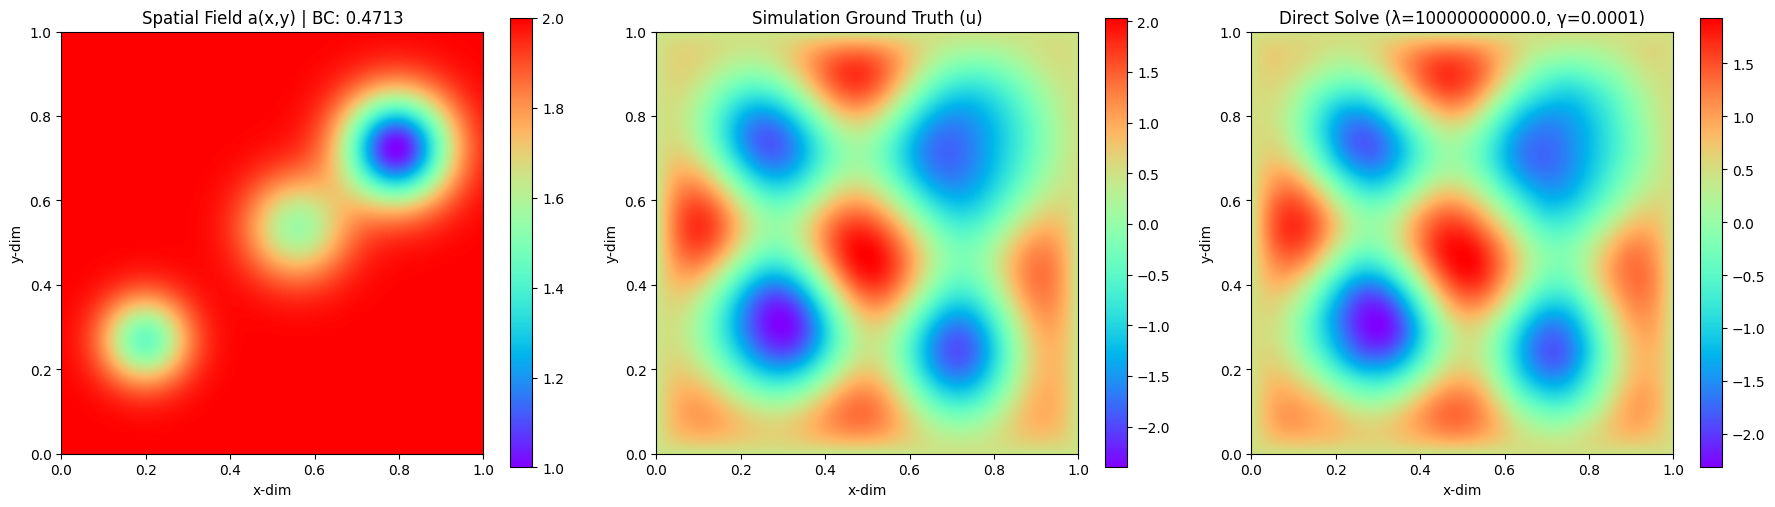

In [11]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
target_lambda = best_params_combo['lambda']
target_tik = best_params_combo['tik_reg']
target_u_pred = all_sweep_preds[(target_lambda, target_tik)]

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = target_u_pred.reshape(nx, ny).T
u_pred_plot = best_u_pred.reshape(nx,  ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]
 
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={target_lambda}, γ={target_tik})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [12]:
import jax.scipy.signal

h_step = 1.0 / 128.0
# The true constant discovered from the dataset
omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

laplacian_kernel = jnp.array([[0.0,  1.0, 0.0],
                              [1.0, -4.0, 1.0],
                              [0.0,  1.0, 0.0]]) / (h_step ** 2)

def discrete_laplacian(grid_2d):
    # mode='valid' strips the 1-pixel outer boundary natively
    return jax.scipy.signal.convolve2d(grid_2d, laplacian_kernel, mode='valid')

# Vectorize to handle the feature dimension: shape (nx, ny, features)
batched_discrete_laplacian = jax.vmap(discrete_laplacian, in_axes=-1, out_axes=-1)

In [13]:
# ==========================================
# DIFFERENTIABLE PSEUDOINVERSE LOOP (WITH PDE AND BC LOSS)
# ==========================================
full_params = load_weights("pretrained_helmholtz_mlp.pkl")

frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = full_params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = full_params['params'][dense_name]

matrix_lmbda = 1e11
sqrt_matrix_lmbda = jnp.sqrt(matrix_lmbda)
tik = 1e-4

@jax.jit
def diff_physics_step_discrete(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr, u_full):
    def compute_all_losses(params):
        # 1. Forward pass the entire grid to extract features
        H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_full, y_full)
        
        # 2. Reshape to 2D grid and compute discrete Laplacian channels
        H_grid = H_flat.reshape(nx, ny, -1)
        H_lap_valid = batched_discrete_laplacian(H_grid) # Shape: (126, 126, 256)
        
        # 3. Slice the valid interior to match the convolution output
        H_valid = H_grid[1:-1, 1:-1, :]
        a_grid = a_full.reshape(nx, ny)
        a_valid = a_grid[1:-1, 1:-1, None] # Add channel axis for broadcasting
        
        # 4. Build Interior PDE Matrix
        A_pde_grid = -H_lap_valid - omega_sq * a_valid * H_valid
        A_pde = A_pde_grid.reshape(-1, H_valid.shape[-1]) # Shape: (15876, 256)
        b_pde = jnp.zeros((A_pde.shape[0], 1))
        
        # 5. Build Boundary Condition Matrix
        A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_bc, y_bc)
        b_bc = bc_val_arr.reshape(-1, 1)
        
        # 6. Differentiable Least Squares Layer
        A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
        B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
        
        I = jnp.eye(A.shape[1])
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w_diff = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
        
        # 7. Compute Pure Unscaled Residuals
        pde_residual = A_pde @ w_diff - b_pde
        bc_residual = A_bc @ w_diff - b_bc
        
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # 8. Compute True Data MSE (Acts as our structural anchor)
        u_pred_flat = H_flat @ w_diff
        mse = jnp.mean((u_pred_flat - u_full) ** 2)
        
        # Return losses with a 1-to-1 match for the VJP function signature
        return (loss_pde_unscaled, loss_bc_unscaled, mse), mse

    # Run Vector-Jacobian Product
    loss_tuple, vjp_fn, mse = jax.vjp(compute_all_losses, current_frozen_params, has_aux=True)
    l_pde, l_bc, l_data = loss_tuple
    
    # Extract independent pure gradients for each term natively
    pde_grads = vjp_fn((1.0, 0.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0, 0.0))[0]
    data_grads = vjp_fn((0.0, 0.0, 1.0))[0]
    
    # Calculate global magnitudes
    pde_norm = optax.global_norm(pde_grads)
    bc_norm = optax.global_norm(bc_grads)
    data_norm = optax.global_norm(data_grads)
    
    # 4. EXECUTE PURE GRADIENT BALANCING (Arbitrary scaling factor weights completely eliminated)
    target_magnitude = 1e4
    
    balanced_pde = jax.tree_util.tree_map(lambda g: (g / (pde_norm + 1e-8)) * target_magnitude, pde_grads)
    balanced_bc = jax.tree_util.tree_map(lambda g: (g / (bc_norm + 1e-8)) * target_magnitude, bc_grads)
    balanced_data = jax.tree_util.tree_map(lambda g: (g / (data_norm + 1e-8)) * target_magnitude, data_grads)
    
    # Construct the final balanced gradient update vector
    total_grads = jax.tree_util.tree_map(
        lambda g1, g2, g3: g1 + g2 + g3, 
        balanced_pde, balanced_bc, balanced_data
    )
    
    return l_pde, l_bc, mse, total_grads, pde_norm, bc_norm, data_norm

Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [14]:
print("Initial Data-Only Pretraining Phase")

l2_error = jnp.linalg.norm(u_sim_plot - u_pred_plot)
l2_ground_truth = jnp.linalg.norm(u_sim_plot)
relative_l2_data = l2_error / l2_ground_truth

print(f"Relative L2 Data Error: {relative_l2_data * 100:.2f}%")

laplacian_pred = discrete_laplacian(u_pred_plot)

a_interior = a_plot[1:-1, 1:-1]
u_pred_interior = u_pred_plot[1:-1, 1:-1]

reaction_term = omega_sq * a_interior * u_pred_interior

physics_error = jnp.linalg.norm(-laplacian_pred - reaction_term)
physics_magnitude = jnp.linalg.norm(reaction_term)
relative_l2_physics = physics_error / physics_magnitude

print(f"Relative L2 Physics Error: {relative_l2_physics * 100:.2f}%")

Initial Data-Only Pretraining Phase
Relative L2 Data Error: 4.14%
Relative L2 Physics Error: 61.59%


In [15]:
meta_optimizer = optax.adamw(learning_rate=1e-5) 
meta_opt_state = meta_optimizer.init(frozen_params)

epochs = 500

# ==========================================
# INITIALIZE LISTS TO TRACK LOSSES
# ==========================================
history_pde = []
history_bc = []
history_data = []
history_total = []

print(f"Starting Balanced Pretrained Physics Loop for {epochs} epochs...")
for epoch in range(epochs):
    
    # Pass full spatial fields directly every step (No random batch shuffling)
    l_pde, l_bc, mse, total_grads, pde_norm, bc_norm, data_norm = diff_physics_step_discrete(
        frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array, u_flat
    )
    
    # Step Adam
    updates, meta_opt_state = meta_optimizer.update(total_grads, meta_opt_state, params=frozen_params)
    frozen_params = optax.apply_updates(frozen_params, updates)
    
    # ==========================================
    # 2. RECORD THE LOSSES
    # ==========================================
    history_pde.append(float(l_pde))
    history_bc.append(float(l_bc))
    history_data.append(float(mse))
    history_total.append(float(l_pde + l_bc + mse))
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:<3} | True Data MSE: {mse:.4e}")
        print(f"            ├─ Raw Residuals  => PDE: {l_pde:.4e} | BC: {l_bc:.4e}")
        print(f"            └─ True Grad Norms => PDE: {pde_norm:.3e} | BC: {bc_norm:.3e} | Data Anchor: {data_norm:.3e}")


Starting Balanced Pretrained Physics Loop for 500 epochs...
Epoch 0   | True Data MSE: 7.9718e-04
            ├─ Raw Residuals  => PDE: 1.5474e+04 | BC: 3.2021e-06
            └─ True Grad Norms => PDE: 4.847e+05 | BC: 2.344e-04 | Data Anchor: 3.694e-01
Epoch 50  | True Data MSE: 5.5317e-03
            ├─ Raw Residuals  => PDE: 7.7225e+03 | BC: 3.7702e-08
            └─ True Grad Norms => PDE: 1.120e+05 | BC: 1.466e-05 | Data Anchor: 9.130e-01
Epoch 100 | True Data MSE: 5.5870e-03
            ├─ Raw Residuals  => PDE: 4.5648e+03 | BC: 1.1728e-08
            └─ True Grad Norms => PDE: 7.000e+04 | BC: 1.038e-05 | Data Anchor: 8.741e-01
Epoch 150 | True Data MSE: 3.0168e-03
            ├─ Raw Residuals  => PDE: 3.0514e+03 | BC: 7.5938e-09
            └─ True Grad Norms => PDE: 4.972e+04 | BC: 1.055e-05 | Data Anchor: 6.406e-01
Epoch 200 | True Data MSE: 6.2397e-04
            ├─ Raw Residuals  => PDE: 2.2772e+03 | BC: 5.5217e-09
            └─ True Grad Norms => PDE: 4.333e+04 | BC: 7.672

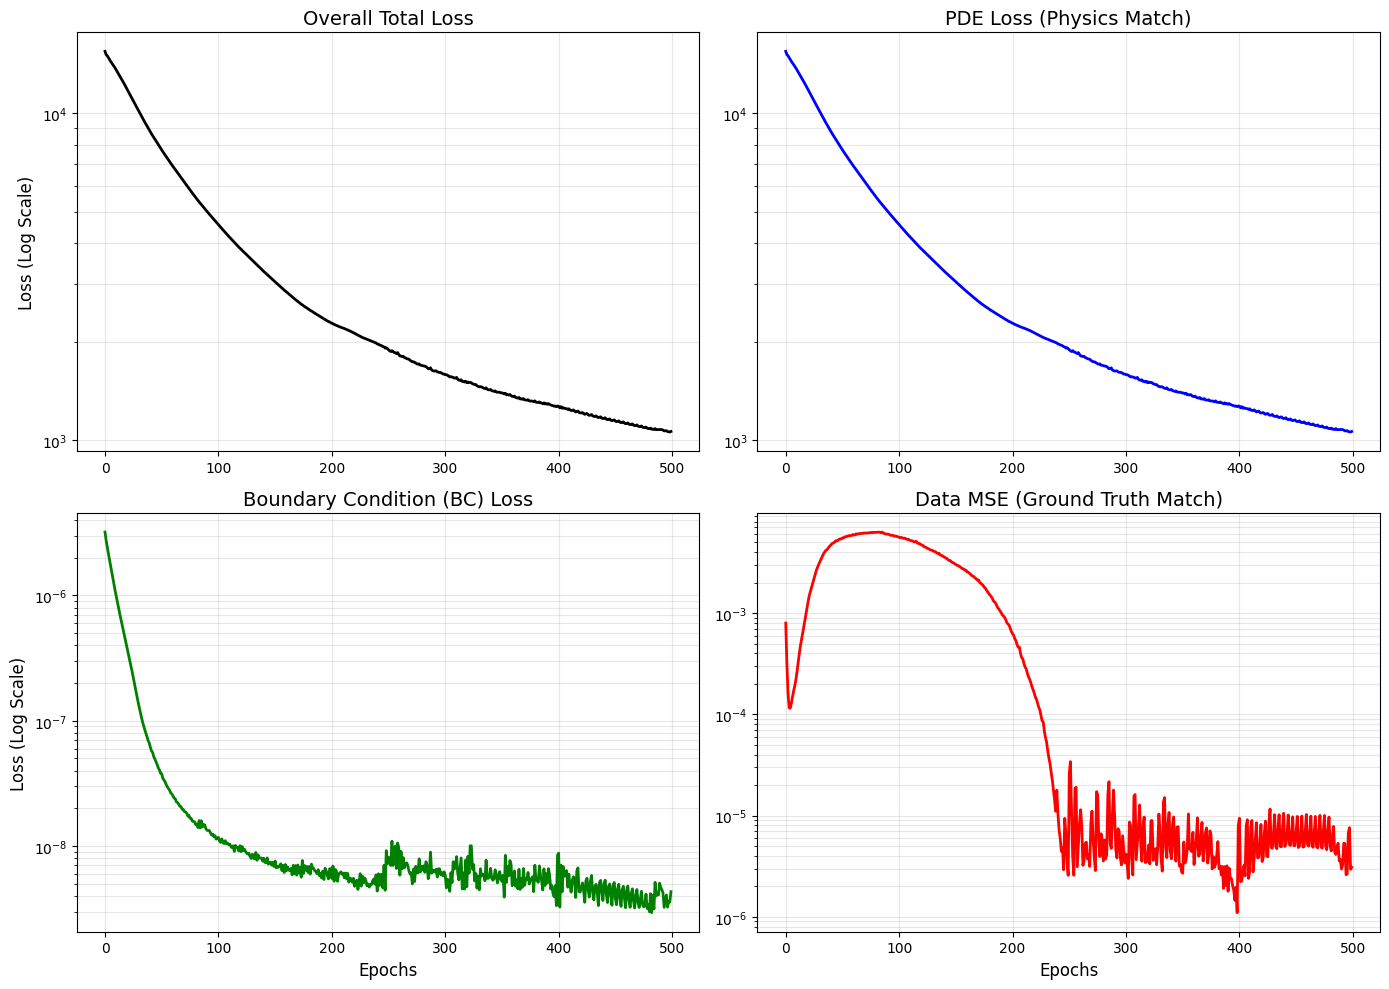

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-Left: Overall Total Loss
axes[0, 0].plot(history_total, color='black', linewidth=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Overall Total Loss', fontsize=14)
axes[0, 0].set_ylabel('Loss (Log Scale)', fontsize=12)
axes[0, 0].grid(True, which="both", ls="-", alpha=0.3)

# Top-Right: PDE Loss
axes[0, 1].plot(history_pde, color='blue', linewidth=2)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('PDE Loss (Physics Match)', fontsize=14)
axes[0, 1].grid(True, which="both", ls="-", alpha=0.3)

# Bottom-Left: BC Loss
axes[1, 0].plot(history_bc, color='green', linewidth=2)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Boundary Condition (BC) Loss', fontsize=14)
axes[1, 0].set_xlabel('Epochs', fontsize=12)
axes[1, 0].set_ylabel('Loss (Log Scale)', fontsize=12)
axes[1, 0].grid(True, which="both", ls="-", alpha=0.3)

# Bottom-Right: Data MSE
axes[1, 1].plot(history_data, color='red', linewidth=2)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Data MSE (Ground Truth Match)', fontsize=14)
axes[1, 1].set_xlabel('Epochs', fontsize=12)
axes[1, 1].grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

Original Adam Weights Shape: (256, 1)
Manual Multiplication MSE (Adam's Weights): 2.0255e-02
Best Pseudoinverse MSE (from Sweep):      1.4119e-03


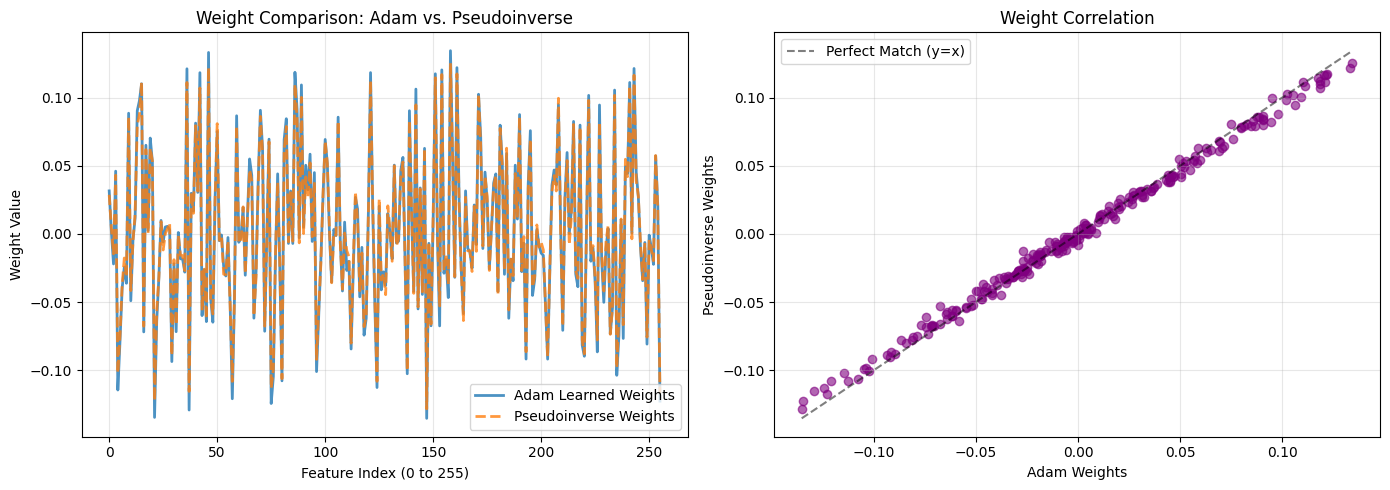

In [17]:
w_learned = params['params']['Dense_4']['kernel']

print(f"Original Adam Weights Shape: {w_learned.shape}")

H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)

# u_pred_manual = (H_full @ w_learned) + b_learned
u_pred_manual = (H_full @ w_learned)

mse_manual = jnp.mean((u_pred_manual - u_flat) ** 2)
print(f"Manual Multiplication MSE (Adam's Weights): {mse_manual:.4e}")
print(f"Best Pseudoinverse MSE (from Sweep):      {best_mse:.4e}")

# ==========================================
# VISUALIZE THE WEIGHTS (Adam vs. Pseudoinverse)
# ==========================================
w_pseudo = best_params_combo['w']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(w_learned, label='Adam Learned Weights', alpha=0.8, linewidth=2)
axes[0].plot(w_pseudo, label='Pseudoinverse Weights', alpha=0.8, linewidth=2, linestyle='dashed')
axes[0].set_title("Weight Comparison: Adam vs. Pseudoinverse", fontsize='large')
axes[0].set_xlabel("Feature Index (0 to 255)")
axes[0].set_ylabel("Weight Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(w_learned, w_pseudo, alpha=0.6, color='purple')
# Add a y=x reference line
min_val = min(jnp.min(w_learned), jnp.min(w_pseudo))
max_val = max(jnp.max(w_learned), jnp.max(w_pseudo))
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Match (y=x)')
axes[1].set_title("Weight Correlation", fontsize='large')
axes[1].set_xlabel("Adam Weights")
axes[1].set_ylabel("Pseudoinverse Weights")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
@jax.jit
def debug_pde_magnitudes(x_val, y_val, a_val):
    # Isolate the forward pass
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    H = get_H(x_val, y_val)
    
    # Calculate second derivatives
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    
    # Calculate the omega term
    reaction_term = omega_sq * a_val * H
    
    # Return the absolute mean of both terms for this specific coordinate
    return jnp.mean(jnp.abs(Laplacian_H)), jnp.mean(jnp.abs(reaction_term))

debug_vmap = jax.jit(vmap(debug_pde_magnitudes))

# Run the test on a chunk of your spatial points
lap_mags, react_mags = debug_vmap(x_sampled[:5000], y_sampled[:5000], a_sampled[:5000])

print(f"Average Magnitude of Laplacian (Network Derivatives): {jnp.mean(lap_mags):.2f}")
print(f"Average Magnitude of Reaction Term (Omega^2 * a * H): {jnp.mean(react_mags):.2f}")

Average Magnitude of Laplacian (Network Derivatives): 999.73
Average Magnitude of Reaction Term (Omega^2 * a * H): 125.38


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import jax.scipy.signal
from jax import vmap, numpy as jnp

# ==========================================
# 1. SETUP: BATCHED 5-POINT STENCIL
# ==========================================
h_step = 1.0 / 128.0
laplacian_kernel = jnp.array([[0.0,  1.0, 0.0],
                              [1.0, -4.0, 1.0],
                              [0.0,  1.0, 0.0]]) / (h_step ** 2)

def discrete_laplacian(grid_2d):
    return jax.scipy.signal.convolve2d(grid_2d, laplacian_kernel, mode='valid')

# Vectorize to handle the 256 feature dimension: shape (nx, ny, features)
batched_discrete_laplacian = jax.vmap(discrete_laplacian, in_axes=-1, out_axes=-1)

# ==========================================
# 2. GET FULL GRID FEATURES
# ==========================================
print("Extracting full grid features...")
def get_H(x_in, y_in):
    return model_frozen.apply(frozen_params, x_in, y_in)

H_flat = vmap(get_H)(x, y)
H_grid = H_flat.reshape(nx, ny, -1)  # Shape: (128, 128, 256)

# ==========================================
# 3. COMPUTE STENCIL LAPLACIAN (DISCRETE)
# ==========================================
print("Computing Stencil Laplacian...")
stencil_lap_grid = batched_discrete_laplacian(H_grid) # Shape: (126, 126, 256)

# ==========================================
# 4. COMPUTE EXACT AD LAPLACIAN (CONTINUOUS)
# ==========================================
print("Computing AD Laplacian grid...")
@jax.jit
def compute_ad_laplacian_grid(params, x_grid, y_grid):
    def get_H_ad(x_in, y_in):
        return model_frozen.apply(params, x_in, y_in)


    def get_laplacian(x_val, y_val):
        H_xx = jax.jacfwd(jax.jacfwd(get_H_ad, argnums=0), argnums=0)(x_val, y_val)
        H_yy = jax.jacfwd(jax.jacfwd(get_H_ad, argnums=1), argnums=1)(x_val, y_val)
        return jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    
    lap_flat = vmap(get_laplacian)(x_grid, y_grid)
    return lap_flat.reshape(nx, ny, -1) 

ad_lap_grid = compute_ad_laplacian_grid(frozen_params, x, y)

# Slice the AD grid interior to perfectly match the 126x126 Stencil output
ad_lap_valid = ad_lap_grid[1:-1, 1:-1, :] # Shape: (126, 126, 256)

# ==========================================
# 5. COMPUTE REACTION TERM (OMEGA^2 * a * H)
# ==========================================
# Reshape and slice 'a' to match the 126x126 valid interior
a_interior = a_flat.reshape(nx, ny)[1:-1, 1:-1, None]  # Shape: (126, 126, 1)
H_interior = H_grid[1:-1, 1:-1, :]                     # Shape: (126, 126, 256)

reaction_term_grid = omega_sq * a_interior * H_interior

# ==========================================
# 6. CALCULATE & PRINT MAGNITUDES
# ==========================================
mean_ad_mag = jnp.mean(jnp.abs(ad_lap_valid))
mean_stencil_mag = jnp.mean(jnp.abs(stencil_lap_grid))
mean_react_mag = jnp.mean(jnp.abs(reaction_term_grid))

print("\n" + "="*50)
print("      PHYSICS MAGNITUDE AUDIT (ALL CHANNELS)")
print("="*50)
print(f"Reaction Term Magnitude:       {mean_react_mag:.4e}")
print("-" * 50)
print(f"5-Point Stencil Magnitude:     {mean_stencil_mag:.4e}")
print(f"Exact AD (jacfwd) Magnitude:   {mean_ad_mag:.4e}")
print("="*50)

if mean_ad_mag > mean_stencil_mag * 10:
    print("\nNote: AD magnitude is massively larger than the Stencil.")
    print("This confirms the continuous physics is amplifying high-frequency Fourier noise.")

Extracting full grid features...
Computing Stencil Laplacian...
Computing AD Laplacian grid...

      PHYSICS MAGNITUDE AUDIT (ALL CHANNELS)
Reaction Term Magnitude:       1.2606e+02
--------------------------------------------------
5-Point Stencil Magnitude:     9.7335e+02
Exact AD (jacfwd) Magnitude:   6.2589e+02


Final True Full-Grid Data MSE: 5.5521e-06


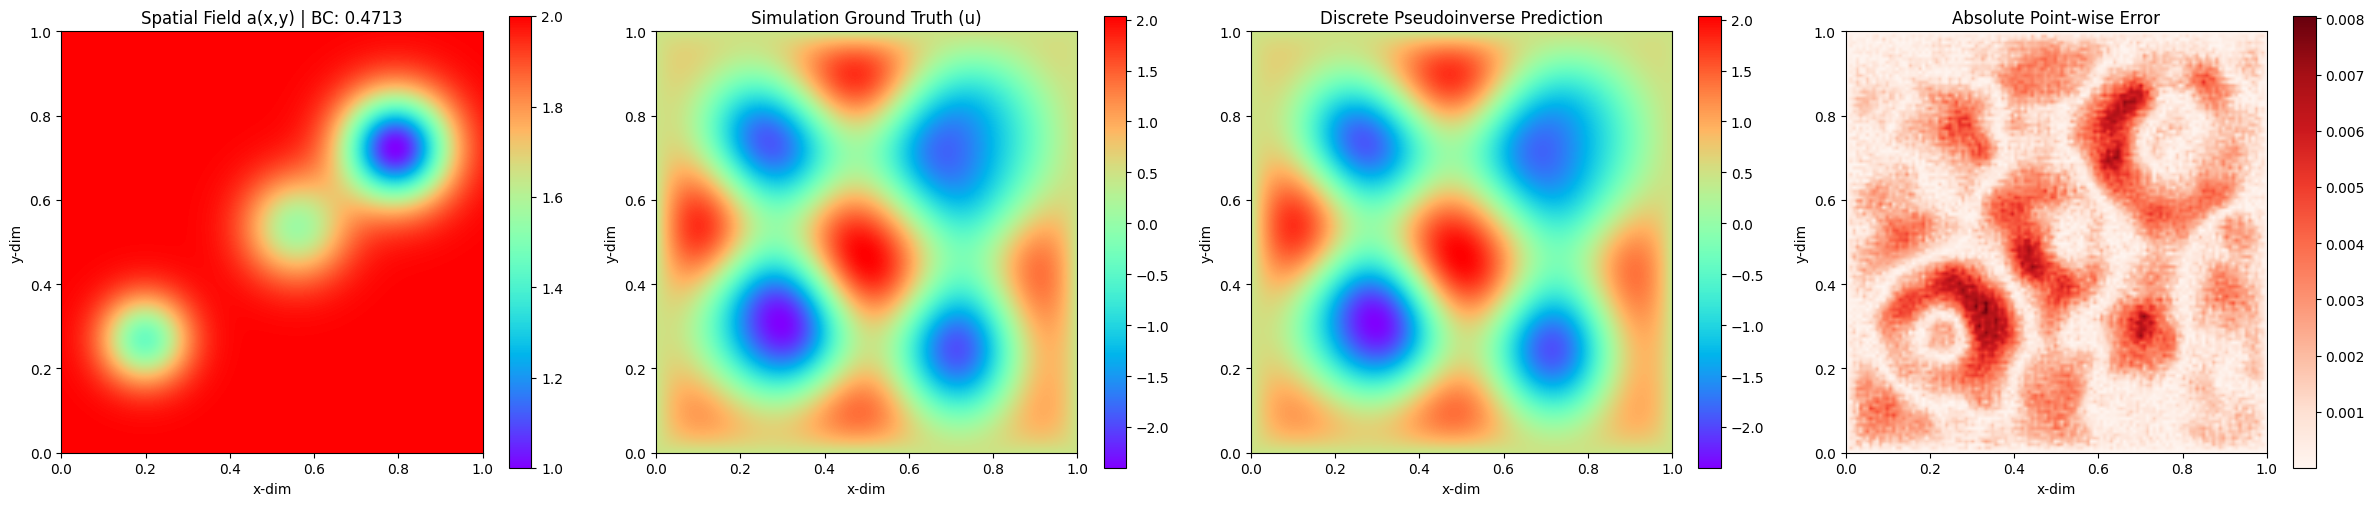

In [20]:
import matplotlib.pyplot as plt

# ==========================================
# 1. DISCRETE PREDICTION FUNCTION
# ==========================================
@jax.jit
def get_discrete_prediction(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr):
    # 1. Extract Full Features
    H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_full, y_full)
    
    # 2. Discrete Laplacian
    H_grid = H_flat.reshape(nx, ny, -1)
    H_lap_valid = batched_discrete_laplacian(H_grid)
    
    # 3. Slice Valid Interior
    H_valid = H_grid[1:-1, 1:-1, :]
    a_grid = a_full.reshape(nx, ny)
    a_valid = a_grid[1:-1, 1:-1, None]
    
    # 4. Assemble PDE (Interior)
    A_pde_grid = -H_lap_valid - omega_sq * a_valid * H_valid
    A_pde = A_pde_grid.reshape(-1, H_valid.shape[-1])
    b_pde = jnp.zeros((A_pde.shape[0], 1))
    
    # 5. Assemble BC
    A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_bc, y_bc)
    b_bc = bc_val_arr.reshape(-1, 1)
    
    # 6. Least Squares Solve
    A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
    B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
    
    I = jnp.eye(A.shape[1])
    A_T_A = A.T @ A
    A_T_B = A.T @ B
    w_final = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
    # 7. Final Output Prediction
    u_pred_flat = H_flat @ w_final
    return u_pred_flat, w_final

# Execute the discrete solve
u_pred_full, final_w = get_discrete_prediction(frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array)

# Calculate final full-grid Data MSE
final_mse = jnp.mean((u_pred_full - u_flat) ** 2)
print(f"Final True Full-Grid Data MSE: {final_mse:.4e}")

# ==========================================
# 2. VISUALIZATION
# ==========================================
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T
error_plot = jnp.abs(u_sim_plot - u_pred_plot)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
ext = [0, 1, 0, 1]

# Lock the color scale of the prediction to the true simulation scale
# This prevents matplotlib from auto-scaling and hiding amplitude collapse
vmin_u = float(jnp.min(u_sim_plot))
vmax_u = float(jnp.max(u_sim_plot))

# Plot 1: Medium
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')

# Plot 2: Ground Truth
mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')

# Plot 3: Network Prediction
mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Discrete Pseudoinverse Prediction', fontsize='large')

# Plot 4: Absolute Error
mesh4 = axes[3].imshow(error_plot, interpolation='bilinear', origin='lower', cmap='Reds', extent=ext, aspect=1.)
fig.colorbar(mesh4, ax=axes[3])
axes[3].set_title('Absolute Point-wise Error', fontsize='large')

for ax in axes:
    ax.set_xlabel('x-dim')
    ax.set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [21]:
print("Post Training Phase")

l2_error = jnp.linalg.norm(u_sim_plot - u_pred_plot)
l2_ground_truth = jnp.linalg.norm(u_sim_plot)
relative_l2_data = l2_error / l2_ground_truth

print(f"Relative L2 Data Error: {relative_l2_data * 100:.2f}%")

# Relative L2 Error (Physics Match)
# Measures how closely the prediction solves the raw Helmholtz equation
# We compare the true discrete Laplacian to the Reaction Term (omega_sq * a * u)
laplacian_pred = discrete_laplacian(u_pred_plot)

# Slice 'a' and 'u' to match the 'valid' mode convolution interior (126x126)
a_interior = a_plot[1:-1, 1:-1]
u_pred_interior = u_pred_plot[1:-1, 1:-1]

reaction_term = omega_sq * a_interior * u_pred_interior

physics_error = jnp.linalg.norm(-laplacian_pred - reaction_term)
physics_magnitude = jnp.linalg.norm(reaction_term)
relative_l2_physics = physics_error / physics_magnitude

print(f"Relative L2 Physics Error: {relative_l2_physics * 100:.2f}%")

Post Training Phase
Relative L2 Data Error: 0.26%
Relative L2 Physics Error: 15.29%
